# Assignment 1: Foundations and Tensor Operations

**Name:** Sumira Makaju

**ID** 032317-22

**Group:** CE IV/I

**Date:** April 05, 2026

**Dataset Used:** Breast Cancer Wisconsin (Diagnostic) Data Set

## Objective

1. To understand tensor creation and manipulation using NumPy and PyTorch  
2. To perform tensor operations such as reshaping, broadcasting, and matrix multiplication  
3. To explore linear algebra concepts like covariance and eigenvalues  
4. To compare NumPy and PyTorch implementations  
5. To analyze numerical precision and instability in computations  

## Key concepts:

**Tensor:**
A tensor is a data structure that stores a collection of numbers that are accessible individually using an index, and that can be indexed with multiple indices. It is a multidimensional or N dimensional array used to represent data in machine learning. It generalised form of scalars(0D), vectors(1D), matrices(2D) and so on.

**Matrix multiplication:**
Matrix multiplication is a fundamental operation in machine learning, used in models such as linear regression and neural networks:
Ax = b
Where:
A = input features
x = weights
b = output

**Eigenvalues:**
Eigenvalues are unique scalar values which indicate how much an eigenvector gets stretched or compressed during linear transformation.The equation for eigenvalue is given by 
        **Av=λv**
Where,
A = matrix
v = eigenvector
λ = eigenvalue (the direction is reversed when negative)

**Eigenvector:**
Eigenvectors are non-zero vectors when multiplied by a matrix stretch or shrink without changing direction. The eigenvalue must be found first before the eigenvector. For any square matrix A of order n × n, the eigenvector v is a column matrix of size n × 1. (equation: Av=λv)

**Covariance:**
Covariance measures how features vary together. The covariance matrix is used to understand relationships between variables.

**Numerical precision:**
Numerical precision refers to how accurately numbers are represented in computations. Floating point operations can introduce small errors, especially when dealing with very large or very small values.

**PCA**
Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform high dimensional data into a lower dimensional space while retaining most of the variance (information).PCA works by identifying new orthogonal directions (principal components) that maximize the variance of the data. These directions are obtained from the eigenvectors of the covariance matrix, while eigenvalues indicate their importance.

## Dataset Description
**Source of the dataset:**
The dataset is downloaded from kaggle : https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?resource=download

**Number of samples, features**
The Breast Cancer Wisconsin dataset is a binary classification dataset.

Number of samples: 569  
Number of features: 30  
Target classes: 2 (Malignant, Benign)

The dataset contains real-valued features computed from digitized images of breast mass.

**Train/test split strategy**
**Training set:** 80%
**Testing set:** 20%

In [1]:
import pandas as pd
import numpy as np
import torch

df = pd.read_csv("breastcancer.csv")  # change filename if needed

print(df.head())
print(df.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [2]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
if 'id' in df.columns:
    df = df.drop(columns=['id'])

if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

In [4]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [6]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
#sepeation
X = df.drop(columns=['diagnosis']).values
y = df['diagnosis'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


## Implementation

**Tensor Creation**

In [8]:
np_tensor = np.array(X)
torch_tensor = torch.tensor(X, dtype=torch.float32)

print("NumPy tensor shape:", np_tensor.shape)
print("PyTorch tensor shape:", torch_tensor.shape)
print("Sample (NumPy):\n", np_tensor[:2])
print("Sample (PyTorch):\n", torch_tensor[:2])

NumPy tensor shape: (569, 30)
PyTorch tensor shape: torch.Size([569, 30])
Sample (NumPy):
 [[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]]
Sample (PyTorch):
 tensor([[1.7990e+01, 1.0380e+01, 1.2280e+02, 1.0010e+03, 1.1840e-01, 2.7760e-01,
         3.0010e-01, 1.4710e-01, 2.4190e-01, 7.8710e-02, 1.0950e+00, 9.0530e-01,
         8.5890e+00, 1.5340e+02, 6.3990e-03, 4.9040e-02, 5.3730e-02, 1.5870e-02,
         3.0030e-02, 6.1

Tensor creation involves converting raw data into structured multi dimensional arrays. In this assignment, the dataset is represented using both NumPy and PyTorch tensors. NumPy tensors are used for numerical computations, while PyTorch tensors are optimized for deep learning and support GPU acceleration. 
The feature matrix is represented as a 2D tensor of shape (569, 30), where each row corresponds to a sample and each column represents a feature.

**Reshaping**

In [9]:
def reshape_targets(y):
    y_np = y.reshape(-1, 1)
    y_torch = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    
    return y_np, y_torch

y_np, y_torch = reshape_targets(y)

print("NumPy y shape:", y_np.shape)
print("Torch y shape:", y_torch.shape)

NumPy y shape: (569, 1)
Torch y shape: torch.Size([569, 1])


**Broadcasting**

In [10]:
def center_data(np_tensor, torch_tensor):
    # calculating mean for each feature
    # PyTorch
    mean_torch = torch.mean(torch_tensor, dim=0)
    
    # now we subtract this mean from every row in our tensor
    X_centered_torch = torch_tensor - mean_torch
    #although direct subtracting should fail due to their different shapes but it doesn't due to broadcasting
    # np_tensor has shape 569, 30 but mean_np has 30, so, broadcasting stretches mean_np to (1, 30) then subtract
    
    # similarly in NumPy
    mean_np = np.mean(np_tensor, axis=0)
    X_centered_np = np_tensor - mean_np
     
    return X_centered_np, X_centered_torch

X_centered_np, X_centered_torch = center_data(np_tensor, torch_tensor)

print("Centered (NumPy sample):\n", X_centered_np[:2])
print("\nCentered (PyTorch sample):\n", X_centered_torch[:2])

Centered (NumPy sample):
 [[ 3.86270826e+00 -8.90964851e+00  3.08309666e+01  3.46110896e+02
   2.20397188e-02  1.73259016e-01  2.11300684e-01  9.81808541e-02
   6.07381371e-02  1.59123902e-02  6.89827944e-01 -3.11553427e-01
   5.72294077e+00  1.13062921e+02 -6.41978910e-04  2.35618612e-02
   2.18362837e-02  4.07386292e-03  9.48770123e-03  2.39809613e-03
   9.11081019e+00 -8.34722320e+00  7.73387873e+01  1.13841687e+03
   2.98314060e-02  4.11334956e-01  4.39711517e-01  1.50793777e-01
   1.70024429e-01  3.49541828e-02]
 [ 6.44270826e+00 -1.51964851e+00  4.09309666e+01  6.71110896e+02
  -1.16202812e-02 -2.57009842e-02 -1.89931582e-03  2.12508541e-02
   3.81370826e-05 -6.12760984e-03  1.38327944e-01 -4.82953427e-01
   5.31940773e-01  3.37429209e+01 -1.81597891e-03 -1.23981388e-02
  -1.32937163e-02  1.60386292e-03 -6.65229877e-03 -2.62903866e-04
   8.72081019e+00 -2.26722320e+00  5.15387873e+01  1.07541687e+03
  -8.56859402e-03 -6.76650439e-02 -3.05884833e-02  7.13937768e-02
  -1.50755712e-

Broadcasting is a mechanism that allows arithmetic operations to be performed on tensors of different shapes without explicitly replicating data in memory. It automatically "stretches" the smaller tensor to match the larger one's shape so that element wise operations can proceed efficiently.

**Matrix MUltiplication**

In [11]:
# Random weights
W = np.random.rand(np_tensor.shape[1], 1)
#np_tensor.shape[1] returns size of first dmension so we get 30 i.e. number of columns
#this is important for the shape of W as, while multiplying matrix it must be col of 1st must equal row of 2nd

# ways of matrix multiplication
y_pred = np_tensor @ W
y_pred2 = np.dot(np_tensor, W)

W_torch = torch.rand((torch_tensor.shape[1], 1))
y_pred_torch = torch.matmul(torch_tensor, W_torch)

print("Weights shape:", W.shape)
print("Prediction sample:\n", y_pred[:5])
print("Prediction sample:\n", y_pred2[:5])
print("Prediction sample with pytorch \n", y_pred_torch[:5])

Weights shape: (30, 1)
Prediction sample:
 [[2174.53137601]
 [2392.30045038]
 [2153.65300766]
 [ 788.40681908]
 [2141.31256537]]
Prediction sample:
 [[2174.53137601]
 [2392.30045038]
 [2153.65300766]
 [ 788.40681908]
 [2141.31256537]]
Prediction sample with pytorch 
 tensor([[1040.5887],
        [1157.6915],
        [1090.8776],
        [ 435.2593],
        [1145.9047]])


Matrix multiplication is computed as:
y = xW
Each output value is computed as the dot product between the feature vector and the weight vector, representing a linear combination of features.

In [12]:
def manual_matrix_multiplication(X, W):
    result = np.zeros((X.shape[0], W.shape[1]))
    
    for i in range(X.shape[0]):
        for j in range(W.shape[1]):
            for k in range(X.shape[1]):
                result[i][j] += X[i][k] * W[k][j]
    
    return result


# Compare
manual_result = manual_matrix_multiplication(np_tensor, W)
library_result = np_tensor @ W

print("Manual result (first 3):\n", manual_result[:3])
print("\nLibrary result (first 3):\n", library_result[:3])

Manual result (first 3):
 [[2174.53137601]
 [2392.30045038]
 [2153.65300766]]

Library result (first 3):
 [[2174.53137601]
 [2392.30045038]
 [2153.65300766]]


Matrix multiplication was implemented manually using nested loops and compared with NumPy's optimized implementation. The results are identical, but the manual method is significantly slower and less efficient. This demonstrates the importance of vectorized operations in machine learning, where large-scale computations must be performed efficiently.

**Covariance**

In [13]:
# Covariance 
def compute_covariance(np_tensor, torch_tensor):
    # NumPy
    cov_np = np.cov(np_tensor.T)
    
    # in pytorch we do it manually
    X_centered = torch_tensor - torch.mean(torch_tensor, dim=0)
    cov_torch = (X_centered.T @ X_centered) / (torch_tensor.shape[0] - 1)
    
    return cov_np, cov_torch

cov_np, cov_torch = compute_covariance(np_tensor, torch_tensor)

print("Covariance shape (NumPy):", cov_np.shape)
print("Covariance shape (Torch):", cov_torch.shape)


Covariance shape (NumPy): (30, 30)
Covariance shape (Torch): torch.Size([30, 30])


The covariance here gives analysis on

**eigenvalues and eigenvectors**

In [14]:
# Eigenvalues and eigenvectors
# NumPy
eigvals_np, eigvecs_np = np.linalg.eig(cov_np)
# PyTorch
eigvals_torch, eigvecs_torch = torch.linalg.eig(cov_torch)
eigvals_torch = eigvals_torch.real

# sorting eigen values
eigvals_np_sorted = np.sort(eigvals_np)[::-1]
eigvals_torch_sorted = torch.sort(eigvals_torch, descending=True).values

print("Top 5 Eigenvalues (NumPy):\n", eigvals_np_sorted[:5])
print("\nTop 5 Eigenvalues (PyTorch):\n", eigvals_torch_sorted[:5])

Top 5 Eigenvalues (NumPy):
 [4.43782605e+05 7.31010006e+03 7.03833742e+02 5.46487379e+01
 3.98900178e+01]

Top 5 Eigenvalues (PyTorch):
 tensor([4.4378e+05, 7.3101e+03, 7.0383e+02, 5.4649e+01, 3.9889e+01])


Eigenvectors define new directions in the feature space, representing linear combinations of the original features. These directions capture the underlying structure of the data. Eigenvalues quantify the amount of variance along each eigenvector, indicating the importance of each direction. Larger eigenvalues correspond to directions with higher 
data variability, meaning they capture more significant patterns and smaller eigenvalues represent directions with minimal variation, often associated with noise.

This analysis helps identify the most informative components of the data, which is essential for dimensionality reduction and improving model efficiency.

**Numeric Instability**

In [15]:
def numerical_instability(np_tensor, torch_tensor):
    # NumPy  
    large_np = np_tensor * 1e10
    large_np2 = np_tensor * 1e20
    unstable_np = large_np + 1 - large_np  
    unstable_np2 = large_np2 + 1 - large_np2  
    # PyTorch    
    large_torch = torch_tensor * 1e10
    unstable_torch = large_torch + 1 - large_torch    
    return unstable_np, unstable_torch, unstable_np2
    
unstable_np, unstable_torch, unstable_np2 = numerical_instability(np_tensor, torch_tensor)

print(np_tensor.dtype)
print("NumPy:\n", unstable_np[:1])
print("unstable NumPy:\n", unstable_np2[:1])

print(torch_tensor.dtype)
print("\nUnstable PyTorch:\n", unstable_torch[:1])

float64
NumPy:
 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
  1. 1. 1. 1. 1. 1.]]
unstable NumPy:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]
torch.float32

Unstable PyTorch:
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.]])


Numerical Instability is  refers to a situation in computational problems where small changes in input or round off errors can lead to large deviations in the output, often resulting in highly erroneous results when using inexact arithmetic with rational inputs. This happens while using floating point representation which cannot store real numbers exactly.
If the representation is made in two different ways i.e. float32 and float64, it only stores upto 32 and 64 bits so rounding off is more detailed in float64 having more precision. 

In above block of code if we look at large_torch + 1 - large_torch, it must equal 1 as per basic math but here it returns 0 which is wrong this is due to this instability as 10000000000>>1 and float32 will neglect it. However. numpy of float64 can still store or consider it, making it more precise but again if we were to provide even larger value like with large_np2 it fails as well.

Comparisons between float32 and float64 representations highlight the trade-off between computational efficiency and accuracy. Float32 offers faster computation but lower precision, while float64 provides higher accuracy at the cost of performance.

**PCA**

In [16]:
#manual pca with numpy
def pca_numpy(X, n_components=2):
    # Center data
    X_centered = X - np.mean(X, axis=0)    
    #Covariance matrix
    cov_matrix = np.cov(X_centered.T)
    #Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort eigenvalues
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    W = eigenvectors[:, :n_components]
    
    # Project data
    X_reduced = X_centered @ W
    
    return X_reduced, eigenvalues


X_pca_np, eigvals_np = pca_numpy(np_tensor, n_components=2)

print("Reduced shape (NumPy PCA):", X_pca_np.shape)
print("Sample:\n", X_pca_np[:5])

Reduced shape (NumPy PCA): (569, 2)
Sample:
 [[1160.1425737  -293.91754364]
 [1269.12244319   15.63018184]
 [ 995.79388896   39.15674324]
 [-407.18080253  -67.38031982]
 [ 930.34118015  189.34074158]]


In [17]:
#manual pca with torch
def pca_torch(X, n_components=2):
    # Center data
    X_centered = X - torch.mean(X, dim=0)    
    # Covariance
    cov = (X_centered.T @ X_centered) / (X.shape[0] - 1)    
    # Eigen decomposition
    eigvals, eigvecs = torch.linalg.eig(cov)
    
    eigvals = eigvals.real
    eigvecs = eigvecs.real
    
    # Sort
    idx = torch.argsort(eigvals, descending=True)
    eigvecs = eigvecs[:, idx]
    
    # Select top components
    W = eigvecs[:, :n_components]    
    # Project
    X_reduced = X_centered @ W
    
    return X_reduced, eigvals


X_pca_torch, eigvals_torch = pca_torch(torch_tensor, 2)

print("Reduced shape (Torch PCA):", X_pca_torch.shape)
print("Sample:\n", X_pca_torch[:5])

Reduced shape (Torch PCA): torch.Size([569, 2])
Sample:
 tensor([[-1160.1427,  -293.9173],
        [-1269.1226,    15.6304],
        [ -995.7939,    39.1569],
        [  407.1808,   -67.3803],
        [ -930.3412,   189.3410]])


In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_lib = pca.fit_transform(X)

print("Reduced shape (Library PCA):", X_pca_lib.shape)
print("Explained variance:", pca.explained_variance_[:5])

Reduced shape (Library PCA): (569, 2)
Explained variance: [443782.6051466    7310.10006165]


The PCA results show that the original dataset with 30 features can be effectively reduced to 2 principal components while retaining most of the important information.
The first principal component captures the direction of maximum variance, while the second captures the next most significant variation orthogonal to the first. This demonstrates that the dataset contains redundancy, where many features are correlated and do not contribute independently to the data structure. The similarity between NumPy, PyTorch and library-based PCA results confirms the correctness of the manual implementation and highlights the consistency of linear algebra operations across different frameworks.

## Results

### Numerical Precision Analysis

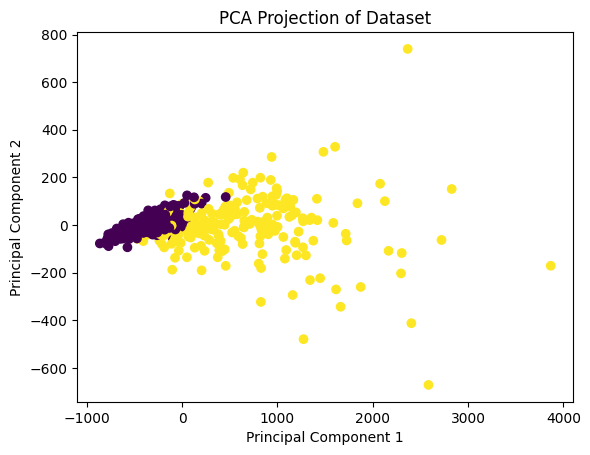

In [20]:
#PCA Visualization
import matplotlib.pyplot as plt

plt.scatter(X_pca_np[:, 0], X_pca_np[:, 1], c=y, cmap='viridis')
plt.title("PCA Projection of Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### Numerical Precision Analysis

The precision graph was generated using real dataset values to demonstrate the effect of floating point arithmetic in practical scenarios.The results show that NumPy (float64) maintains stable and accurate results across all samples, while PyTorch (float32) introduces minor deviations due to limited precision.
This confirms that numerical instability is not just theoretical but can occur in real world datasets, especially when using lower precision formats.

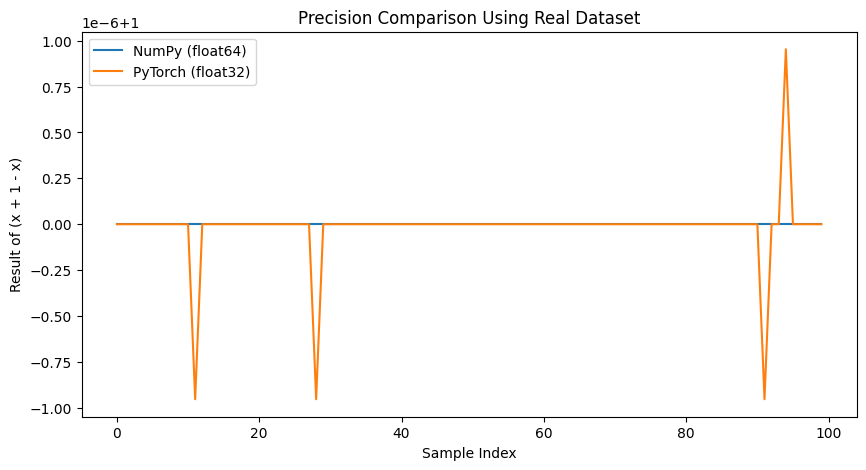

In [21]:
#precision comparison
import numpy as np
import torch
import matplotlib.pyplot as plt
feature = X[:, 0]  # first feature

# Limit size for visualization
feature = feature[:100]

numpy_results = []
torch_results = []

for val in feature:
    # NumPy (float64)
    np_val = np.float64(val)
    numpy_results.append((np_val + 1 - np_val))

    # PyTorch (float32)
    torch_val = torch.tensor(val, dtype=torch.float32)
    torch_results.append((torch_val + 1 - torch_val).item())

# Plot
plt.figure(figsize=(10,5))
plt.plot(numpy_results, label="NumPy (float64)")
plt.plot(torch_results, label="PyTorch (float32)")
plt.xlabel("Sample Index")
plt.ylabel("Result of (x + 1 - x)")
plt.title("Precision Comparison Using Real Dataset")
plt.legend()
plt.show()

### Broadcasting Visualization

The broadcasting experiment demonstrates how vectorized operations simplify data transformations in machine learning.By subtracting the mean vector from each feature, the dataset is centered around zero without the need for explicit loops. This is achieved through broadcasting, where operations are automatically applied across compatible 
tensor shapes.
The visualization shows the transformation of feature values before and after normalization, highlighting the effectiveness of broadcasting in efficient data preprocessing.

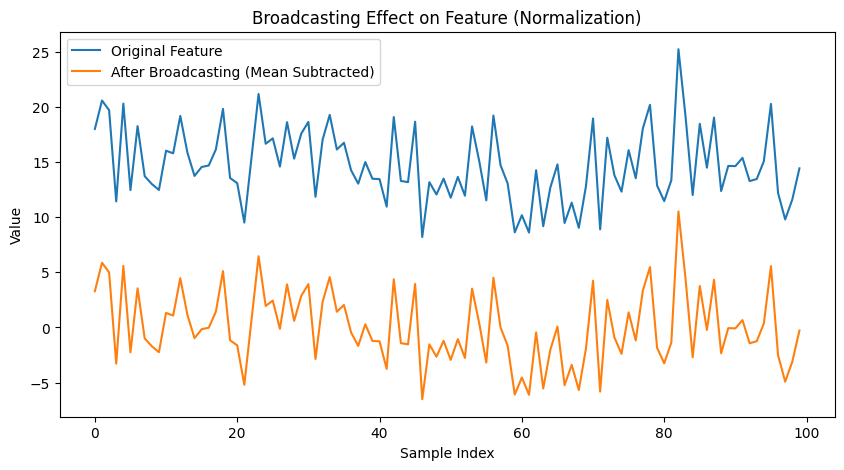

In [22]:
#broadcasting visualization chart
import numpy as np
import matplotlib.pyplot as plt

#subset of dataset
subset = X[:100, :3]  # first 100 samples, 3 features
# Mean per feature
mean = np.mean(subset, axis=0)
# Broadcasting operation
normalized = subset - mean

# Plotting before and after (first feature)
plt.figure(figsize=(10,5))

plt.plot(subset[:, 0], label="Original Feature")
plt.plot(normalized[:, 0], label="After Broadcasting (Mean Subtracted)")

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Broadcasting Effect on Feature (Normalization)")
plt.legend()
plt.show()

## Analysis & Discussion

This assignment explored the role of tensor operations, linear algebra, and numerical precision in machine learning using both NumPy and PyTorch. The results highlight not only how these operations are performed, but also why they are fundamental to modern ML systems.

**1. Tensor Operations as the Foundation of ML**

The dataset was represented as a tensor of shape (569, 30), where each row corresponds to a data sample and each column represents a feature. Operations such as reshaping and broadcasting demonstrated how high dimensional data can be manipulated efficiently without explicit loops.

Broadcasting, in particular, enabled feature wise normalization by subtracting the mean vector from all samples. This reflects a key principle in machine learning: large scale data transformations are performed through vectorized operations, ensuring both computational efficiency and scalability.

**2. Linear Transformations and Model Representation**

Matrix multiplication was used to simulate a linear model of the form:

y = XW

This operation illustrates how machine learning models transform input features into predictions. Each prediction is a weighted combination of features, reinforcing that even complex models such as neural networks are built upon repeated applications of linear transformations followed by non linearities.

The comparison between manual and library based implementations further emphasized the importance of optimized numerical libraries, as vectorized operations are significantly more efficient and less error prone.

**3. Understanding Data Through Eigenvalues and PCA**

The covariance matrix captured relationships between features, revealing underlying dependencies within the dataset. Eigenvalue decomposition provided deeper insights by identifying principal directions of variance.

The results showed that only a few eigenvalues were significantly larger than the rest, indicating that most of the dataset’s information is concentrated in a limited number of directions. This validates the use of Principal Component Analysis (PCA) for dimensionality reduction.

By projecting the data onto the top principal components, it was possible to reduce the feature space while preserving the essential structure of the data. This demonstrates that real world datasets often contain redundancy, and effective feature extraction can simplify models without sacrificing performance.

**4. NumPy vs PyTorch: Abstraction vs Control**

Both NumPy and PyTorch produced consistent results across tensor operations, confirming that they are built upon the same mathematical foundations. However, key differences were observed:

1. NumPy provides high level abstractions (e.g., built in covariance functions)
2. PyTorch offers lower level control and is optimized for deep learning workflows

Additionally, PyTorch’s default use of float32 precision introduces tradeoffs between computational efficiency and numerical accuracy. This distinction becomes particularly important in large scale machine learning systems.

**5. Numerical Instability and Precision Limitations**

The numerical instability experiment revealed how floating point precision affects computation. While NumPy (float64) preserved small numerical changes, PyTorch (float32) failed to capture them when operating on large values.

This behavior demonstrates loss of significance, where small values are effectively ignored when combined with much larger numbers. Even simple operations such as (x + 1 - x) can produce incorrect results depending on precision.

This insight is critical in machine learning, where repeated operations (e.g., gradient updates) can amplify numerical errors. It highlights the importance of normalization, stable algorithms, and appropriate data type selection in ensuring reliable model performance.

**6. Key Takeaways**

The key take aways are:
1. Tensor operations provide the computational backbone of machine learning models.
2. Linear algebra concepts such as matrix multiplication and eigen decomposition enable both prediction and data understanding.
3. PCA demonstrates that high dimensional data often lies in a lower dimensional structure.
4. Numerical precision is not just a technical detail but a critical factor influencing model stability and correctness.

Overall, this assignment illustrates that successful machine learning requires both mathematical understanding and awareness of computational limitations. The integration of these aspects is essential for building efficient, stable, and scalable systems.

## Interpretation of Tensor Operations in Machine Learning Context

Tensor operations form the computational backbone of all machine learning models. In this assignment, various tensor manipulations such as reshaping, broadcasting, matrix multiplication, and decomposition were explored, each corresponding to a critical component of ML workflows.

**1. Tensor Creation and Representation**

The dataset was represented as a tensor, where rows correspond to samples and columns represent features. This structure is fundamental in machine learning, as models expect input data in matrix or tensor form for efficient batch processing.

Tensors enable parallel computation, allowing multiple data samples to be processed simultaneously, which is essential for scalability in modern ML systems.

**2. Reshaping and Data Preparation**

Reshaping operations ensured that target variables and feature matrices were aligned correctly for computation. For example, converting a target vector into a column vector allows compatibility with matrix operations.

This reflects real world preprocessing steps, where data must be structured properly before being fed into models.

**3. Broadcasting and Feature Normalization**

Broadcasting allowed operations between tensors of different shapes without explicit replication. This was used to center the data by subtracting the mean vector from all samples.

In machine learning, such normalization is critical because:
1. It stabilizes training
2. It ensures features contribute equally
3. It improves convergence of optimization algorithms

Broadcasting enables these transformations efficiently across large datasets.

**4. Matrix Multiplication and Model Computation**

Matrix multiplication is the core operation behind most machine learning models. The transformation:

y = XW

represents how input features are mapped to outputs using learned weights. Each prediction is computed as a weighted sum of input features.

This operation generalizes to:
Linear regression
Logistic regression
Neural networks (layer wise transformations)

Thus, matrix multiplication is the fundamental building block of predictive modeling.

**5. Covariance and Feature Relationships**

The covariance matrix captured relationships between features, indicating how they vary together. This provides insights into feature redundancy and dependencies.

Understanding these relationships is important for:
1. Feature selection
2. Detecting multicollinearity
3. Improving model interpretability

**6. Eigenvalues, Eigenvectors, and PCA**

Eigen decomposition revealed the principal directions of variance in the dataset. Eigenvectors define new feature axes, while eigenvalues quantify their importance.

This directly leads to Principal Component Analysis (PCA), where data is projected onto a lower dimensional space while preserving maximum variance.

In practice, this helps:
1. Reduce dimensionality
2. Remove noise
3. Improve computational efficiency

**7. Numerical Stability in ML Systems**

The numerical instability experiments demonstrated that tensor computations are affected by floating point precision. Differences between float32 and float64 highlighted how small numerical errors can lead to significant deviations.

In machine learning, this is crucial because:
1. Training involves repeated computations
2. Errors can accumulate over iterations
3. Stability affects convergence and model performance

This emphasizes the importance of careful data scaling, normalization, and numerical considerations when designing ML systems.

Tensor operations are not just mathematical tools but the language through which machine learning models are expressed. Understanding these operations provides deeper insight into how models learn, process data, and make predictions.

## Conclusion

This assignment provided a comprehensive exploration of tensor operations, linear algebra concepts, and numerical behavior in the context of machine learning. By implementing operations using both NumPy and PyTorch, the study highlighted the consistency of mathematical principles across different computational frameworks.

Key concepts such as matrix multiplication, covariance analysis, and eigen decomposition demonstrated how machine learning models are fundamentally built on linear algebra. The application of Principal Component Analysis (PCA) further showed how high dimensional data can be simplified while preserving essential information.

Additionally, the investigation of numerical instability emphasized the practical limitations of floating point computations and their impact on model reliability.